<a href="https://colab.research.google.com/github/crystalclcm/Dissertation-Crystal-Matticks/blob/main/02_job_ads_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import and Upload

In [10]:
import requests
import pandas as pd

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Easilet Lease Control Sheet.xlsx',
 'Easilet Lease Control Sheet.gsheet',
 'Car Spaces  Byrne Moore.xls',
 'Car Spaces  Byrne Moore.gsheet',
 'BW Contact Listing.xlsx',
 'BW Contact Listing.gsheet',
 'RH Customer listing.xlsx',
 'Parking control listing.xlsx',
 'Parking control listing.gsheet',
 'RH Customer listing.gsheet',
 'GLS Customer Listing.xlsx',
 'GLS Customer Listing.gsheet',
 'BM Listing.xlsx',
 'BM Listing.gsheet',
 'GCV Supplier Listing.xlsx',
 'GCV Supplier Listing.gsheet',
 'lease of unit 5, bymac(part 1).pdf',
 '30A BW lease agreement (second half).pdf',
 '30A BW lease agreement (first half).pdf',
 'lease of unit 5, bymac(part 2).pdf',
 '6 ferndale road letter of engagement.pdf',
 '36 st. fintan villas letter of engagement.pdf',
 '36 st. fintan villas lease agreement (part 1).pdf',
 '36 st.fintan villas lease agreement (part 2).pdf',
 '68 st. fintan villas letter of engagement.pdf',
 'index.pdf',
 'Document31 (2).pdf',
 'Document31 (2).gdoc',
 'Colab Notebooks',
 'Unt

In [12]:
pre_ai = pd.read_csv('/content/drive/MyDrive/pre_ai_full.csv')
post_ai = pd.read_csv('/content/adzuna_post_ai_final.csv')



In [13]:
Job_Postings = pd.read_csv('/content/JobPostings.csv')


In [14]:
pre_ai.columns


Index(['job_title', 'job_description', 'country', 'date_posted', 'source',
       'role', 'source_clean', 'skills'],
      dtype='object')

In [15]:
post_ai.columns


Index(['job_title', 'job_description', 'country', 'date_posted', 'source',
       'role'],
      dtype='object')

# standardise and align datasets

In [16]:
import pandas as pd


pre_ai_clean = pre_ai.copy()

pre_ai_clean = pre_ai_clean.rename(columns={
    'job_title': 'job_title',
    'job_description': 'raw_text',
    'date_posted': 'date_posted',
    'source_clean': 'source',
    'skills': 'skills_text'
})

post_ai_clean = post_ai.copy()

post_ai_clean = post_ai_clean.rename(columns={
    'job_title': 'job_title',
    'description': 'raw_text',
    'created': 'date_posted',
    'company': 'company',
    'location': 'location',
    'redirect_url': 'redirect_url'
})

post_ai_extra_clean = Job_Postings.copy()

post_ai_extra_clean = post_ai_extra_clean.rename(columns={
    'title': 'job_title',
    'full_description': 'raw_text',
    'created': 'date_posted',
    'skills_list': 'skills_text',
    'home_url': 'home_url'
})

unified_columns = [
    'job_title', 'company', 'location', 'country', 'date_posted', 'role',
    'source', 'industry', 'contract_type', 'contract_time',
    'salary_min', 'salary_max', 'salary_avg',
    'raw_text', 'clean_text', 'skills_text', 'seniority',
    'redirect_url', 'home_url'
]

for df in [pre_ai_clean, post_ai_clean, post_ai_extra_clean]:
    for col in unified_columns:
        if col not in df.columns:
            df[col] = None

pre_ai_clean = pre_ai_clean[unified_columns]
post_ai_clean = post_ai_clean[unified_columns]
post_ai_extra_clean = post_ai_extra_clean[unified_columns]

print("Standardisation complete.")


Standardisation complete.


In [17]:
def basic_clean(text):
    if pd.isna(text):
        return None
    text = str(text)
    text = text.lower()
    text = text.replace("\n", " ")
    text = " ".join(text.split())
    return text

pre_ai_clean["clean_text"] = pre_ai_clean["raw_text"].apply(basic_clean)
post_ai_clean["clean_text"] = post_ai_clean["raw_text"].apply(basic_clean)
post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)

print("Basic cleaning done.")


Basic cleaning done.


/tmp/ipykernel_23038/3995996791.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)


In [18]:
print("PRE-AI duplicates:", pre_ai_clean.columns.duplicated().any())
print("POST-AI duplicates:", post_ai_clean.columns.duplicated().any())
print("EXTRA POST-AI duplicates:", post_ai_extra_clean.columns.duplicated().any())


PRE-AI duplicates: True
POST-AI duplicates: False
EXTRA POST-AI duplicates: False


In [19]:
# Remove duplicate columns from PRE-AI
pre_ai_clean = pre_ai_clean.loc[:, ~pre_ai_clean.columns.duplicated()]
print("PRE-AI duplicate columns removed.")


PRE-AI duplicate columns removed.


In [20]:
# Find columns all datasets share
common_cols = list(
    set(pre_ai_clean.columns) &
    set(post_ai_clean.columns) &
    set(post_ai_extra_clean.columns)
)

print("Number of shared columns:", len(common_cols))
print("Shared columns:", common_cols)


Number of shared columns: 19
Shared columns: ['location', 'home_url', 'clean_text', 'salary_max', 'source', 'contract_type', 'raw_text', 'company', 'seniority', 'redirect_url', 'contract_time', 'salary_min', 'role', 'skills_text', 'job_title', 'country', 'industry', 'date_posted', 'salary_avg']


In [21]:
pre_ai_clean = pre_ai_clean[common_cols]
post_ai_clean = post_ai_clean[common_cols]
post_ai_extra_clean = post_ai_extra_clean[common_cols]

print("Columns aligned.")


Columns aligned.


In [22]:
pre_ai_clean["ai_period"] = "pre_ai"
post_ai_clean["ai_period"] = "post_ai"
post_ai_extra_clean["ai_period"] = "post_ai"


In [23]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


/tmp/ipykernel_23038/1891809547.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  job_ads_clean = pd.concat(


In [24]:
job_ads_clean["date_posted"].max()


'2026-04-14T16:25:23Z'

In [25]:
ads = job_ads_clean.copy()


In [26]:
ads["year"] = ads["date_posted"].astype(str).str[:4]
ads["year"] = ads["year"].astype(int)


In [27]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

german_stopwords = {"der","die","das","des","den","dem","ein","eine","einer","einem","als","und","mit","auf","im","in","am","op","al","er","met"}

stopwords = ENGLISH_STOP_WORDS.union(german_stopwords)

job_ads_clean["clean_text"] = job_ads_clean["clean_text"].apply(
    lambda x: " ".join(
        w for w in (x or "").split()
        if w not in stopwords and len(w) > 2
    )
)



In [28]:
job_ads_clean["ai_period"].value_counts()


,count
ai_period,
pre_ai,13036
post_ai,2867


In [29]:
job_ads_clean[job_ads_clean["ai_period"] == "post_ai"].shape


(2867, 20)

In [30]:
post_ai["role"].value_counts(dropna=False)


,count
role,
business_analyst,149
data_analyst,147
software_engineer,147
accountant,139


In [31]:
job_ads_clean["clean_text"] = job_ads_clean["clean_text"].fillna("")


# Load ONET

In [32]:
import pandas as pd

skills_df = pd.read_excel("Skills.xlsx")
knowledge_df = pd.read_excel("Knowledge.xlsx")
abilities_df = pd.read_excel("Abilities.xlsx")

skills_df.head(), knowledge_df.head(), abilities_df.head()


(  O*NET-SOC Code             Title Element ID           Element Name Scale ID  \
 0     11-1011.00  Chief Executives    2.A.1.a  Reading Comprehension       IM   
 1     11-1011.00  Chief Executives    2.A.1.a  Reading Comprehension       LV   
 2     11-1011.00  Chief Executives    2.A.1.b       Active Listening       IM   
 3     11-1011.00  Chief Executives    2.A.1.b       Active Listening       LV   
 4     11-1011.00  Chief Executives    2.A.1.c                Writing       IM   
 
    Scale Name  Data Value  N  Standard Error  Lower CI Bound  Upper CI Bound  \
 0  Importance        4.12  8          0.1250          3.8800          4.3700   
 1       Level        4.62  8          0.1830          4.2664          4.9836   
 2  Importance        4.00  8          0.0000          4.0000          4.0000   
 3       Level        4.75  8          0.1637          4.4292          5.0708   
 4  Importance        4.12  8          0.1250          3.8800          4.3700   
 
   Recommend Suppr

In [33]:
def build_onet_terms(df, name_col="Element Name", extra_cols=None):
    cols = [name_col]
    if extra_cols:
        cols += extra_cols
    cols = [c for c in cols if c in df.columns]

    terms = set()
    for col in cols:
        terms.update(
            df[col]
            .dropna()
            .astype(str)
            .str.lower()
            .str.strip()
            .tolist()
        )
    return terms

onet_skill_terms = build_onet_terms(skills_df, name_col="Element Name")
onet_knowledge_terms = build_onet_terms(knowledge_df, name_col="Element Name")
onet_ability_terms = build_onet_terms(abilities_df, name_col="Element Name")

onet_terms = onet_skill_terms | onet_knowledge_terms | onet_ability_terms
len(onet_terms)


119

### Skill extraction and merging

In [34]:

skill_list = [

    #technical/data
    "python", "sql", "excel", "java", "sas",
    "aws", "gcp", "azure", "spark",
    "tableau", "power bi", "matlab", "r",

    #finance/business
    "finance", "valuation", "derivatives", "risk management",
    "tax", "vat", "accounting", "budgeting",

    #Pharma/validation/Engineering
    "validation", "qualification", "calibration",
    "change control", "qms", "gmp", "csv",
    "equipment validation", "process validation",
    "cleaning validation", "iq", "oq", "pq",
    "capa", "deviation management",
    "quality assurance", "quality control",
    "pharmaceutical", "biotech", "manufacturing",

    #Softer Skills
    "communication", "analytical", "leadership",
    "collaboration", "problem solving", "teamwork",
    "attention to detail", "documentation",
    "project management", "stakeholder management",

    #Compliance/Regulatory
    "compliance", "regulatory", "audit", "sop"
]



In [35]:
skill_synonyms = {
    "excel": ["ms excel", "microsoft excel", "spreadsheet"],
    "python": ["python3", "py"],
    "sql": ["mysql", "postgres", "sql server"],
    "gcp": ["google cloud", "google cloud platform"],
    "aws": ["amazon web services", "ec2", "s3"],
    "azure": ["microsoft azure"],
    "communication": ["communication skills", "communicator"],
    "leadership": ["lead", "manage", "management"],
    "problem solving": ["problem-solving", "problem solving"],
    "validation": ["process validation", "equipment validation", "cleaning validation"],
    "csv": ["computer system validation"],
    "qms": ["quality management system"],
    "gmp": ["good manufacturing practice"],
    "capa": ["corrective and preventive action"],
}


In [36]:
import re

def extract_skills(text, skills, synonyms):
    if pd.isna(text):
        return []

    text = text.lower()
    text = re.sub(r"[-/]", " ", text)

    found = set()

    # direct matches
    for skill in skills:
        skill_norm = skill.lower()
        if re.search(rf"\b{re.escape(skill_norm)}\b", text):
            found.add(skill)

    # synonym matches
    for skill, syns in synonyms.items():
        for syn in syns:
            syn_norm = syn.lower()
            if re.search(rf"\b{re.escape(syn_norm)}\b", text):
                found.add(skill)

    return list(found)


In [37]:
print(ads.columns.tolist())


['location', 'home_url', 'clean_text', 'salary_max', 'source', 'contract_type', 'raw_text', 'company', 'seniority', 'redirect_url', 'contract_time', 'salary_min', 'role', 'skills_text', 'job_title', 'country', 'industry', 'date_posted', 'salary_avg', 'ai_period', 'year']


In [38]:
def extract_skills(text, skills):
    if pd.isna(text):
        return []

    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found


In [39]:
pre_ai_clean["extracted_skills"] = pre_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_clean["extracted_skills"] = post_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_extra_clean["extracted_skills"] = post_ai_extra_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [40]:
job_ads_clean["extracted_skills"] = job_ads_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [41]:
from collections import Counter

all_skills = job_ads_clean["extracted_skills"].sum()
skill_counts = Counter(all_skills)

skill_counts


Counter({'excel': 8493,
         'r': 15321,
         'vat': 7739,
         'iq': 3509,
         'pharmaceutical': 1838,
         'biotech': 681,
         'communication': 7630,
         'analytical': 2943,
         'manufacturing': 2323,
         'risk management': 563,
         'validation': 1820,
         'gmp': 862,
         'problem solving': 2132,
         'documentation': 2797,
         'project management': 1613,
         'qualification': 5271,
         'capa': 3447,
         'leadership': 2485,
         'collaboration': 2153,
         'finance': 2062,
         'quality assurance': 725,
         'compliance': 2656,
         'regulatory': 1755,
         'audit': 1774,
         'calibration': 122,
         'change control': 412,
         'qms': 143,
         'csv': 200,
         'equipment validation': 82,
         'oq': 220,
         'pq': 393,
         'sop': 868,
         'python': 3034,
         'java': 2476,
         'sas': 614,
         'sql': 3230,
         'gcp': 617,
   

In [42]:
skill_counts_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])
skill_counts_df.sort_values("count", ascending=False)


,count
r,15321
excel,8493
vat,7739
communication,7630
qualification,5271
iq,3509
capa,3447
sql,3230
python,3034
analytical,2943


In [43]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


/tmp/ipykernel_23038/1891809547.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  job_ads_clean = pd.concat(


In [44]:
df = job_ads_clean.copy()


In [45]:
job_ads_clean.columns


Index(['location', 'home_url', 'clean_text', 'salary_max', 'source',
       'contract_type', 'raw_text', 'company', 'seniority', 'redirect_url',
       'contract_time', 'salary_min', 'role', 'skills_text', 'job_title',
       'country', 'industry', 'date_posted', 'salary_avg', 'ai_period',
       'extracted_skills'],
      dtype='object')

In [46]:
job_ads_clean["extracted_skills"].head()


,extracted_skills
0,"[excel, r, vat, iq, pharmaceutical, biotech, c..."
1,"[excel, r, vat, pharmaceutical, manufacturing]"
2,"[excel, r, risk management, validation, gmp, m..."
3,"[excel, r, vat, pharmaceutical, manufacturing]"
4,"[excel, r, vat, qualification, capa, pharmaceu..."


# Build the tfidf model

In [47]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


In [48]:
noise_terms = [
    r"income statement[s]?",
    r"balance sheet[s]?",
    r"year[- ]?end",
    r"month[- ]?end",
    r"financial reporting",
    r"financial statement[s]?",
    r"accrual[s]?",
    r"journal entries?",
    r"gaap",
    r"ifrs",
    r"cost control",
    r"\baca\b",
    r"\bacca\b",
    r"\baudit(ing)?\b"
]


In [49]:
def clean_text(text):
    if text is None or pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    for term in noise_terms:
        text = text.replace(term, " ")

    return text


In [50]:
job_ads_clean["clean_text_no_noise"] = job_ads_clean["clean_text"].apply(clean_text)


In [51]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,       # ignore noise
    max_df=0.8,     # ignore overly common terms
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(job_ads_clean["clean_text_no_noise"])
feature_names = vectorizer.get_feature_names_out()


In [52]:
import numpy as np

def top_terms_from_sparse(row, feature_names, top_n=10):
    # row is a sparse matrix row
    data = row.data
    indices = row.indices

    if len(data) == 0:
        return []

    top_idx = data.argsort()[-top_n:]
    return [feature_names[indices[i]] for i in top_idx]

job_ads_clean["tfidf_top_terms"] = [
    top_terms_from_sparse(tfidf_matrix[i], feature_names)
    for i in range(tfidf_matrix.shape[0])
]


In [53]:
from collections import Counter
Counter([t for sub in job_ads_clean["tfidf_top_terms"] for t in sub]).most_common(50)


[('data', 2392),
 ('sales', 869),
 ('business', 738),
 ('software', 573),
 ('ai', 444),
 ('design', 443),
 ('project', 436),
 ('equipment', 414),
 ('manufacturing', 410),
 ('test', 371),
 ('quality', 368),
 ('engineering', 365),
 ('security', 363),
 ('accounting', 350),
 ('cloud', 347),
 ('automation', 345),
 ('customer', 342),
 ('validation', 336),
 ('analytics', 320),
 ('financial', 307),
 ('process', 300),
 ('product', 291),
 ('development', 262),
 ('medical', 257),
 ('clinical', 253),
 ('accounts', 252),
 ('net', 244),
 ('accountant', 240),
 ('customers', 232),
 ('technical', 225),
 ('ll', 216),
 ('finance', 215),
 ('testing', 214),
 ('developer', 211),
 ('reperio', 206),
 ('amazon', 201),
 ('maintenance', 198),
 ('systems', 196),
 ('sigmar', 193),
 ('business development', 191),
 ('network', 191),
 ('preparation', 191),
 ('service', 189),
 ('management', 188),
 ('qa', 187),
 ('electrical', 187),
 ('azure', 186),
 ('learning', 186),
 ('hr', 184),
 ('support', 181)]

# build role classifier

In [54]:
ads["role_text"] = (
    ads["job_title"].fillna("").astype(str).str.lower() + " " +
    ads["clean_text"].fillna("").astype(str).str.lower()
)


In [55]:
def classify_role(title):
    if pd.isna(title):
        return "Other"
    t = title.lower()

    if "data scientist" in t or "machine learning" in t:
        return "Data Science"
    if "software" in t or "developer" in t:
        return "Software Engineering"
    if "business analyst" in t:
        return "Business Analysis"
    if "project manager" in t:
        return "Project Management"
    if "product manager" in t:
        return "Product Management"
    if "marketing" in t:
        return "Marketing"
    if "finance" in t:
        return "Finance"
    if "accountant" in t:
        return "Accounting"
    if "operations" in t or "supply chain" in t:
        return "Operations"
    if "consultant" in t:
        return "Consulting"
    if "cyber" in t or "security" in t:
        return "Cybersecurity"
    if "cloud" in t or "aws" in t or "azure" in t:
        return "Cloud Engineering"
    if "qa" in t or "quality assurance" in t:
        return "Quality Assurance"
    if "hr" in t or "human resources" in t:
        return "HR"
    if "engineer" in t:
        return "Engineering"

    return "Other"

job_ads_clean["role_group"] = job_ads_clean["job_title"].apply(classify_role)


In [56]:
job_ads_clean["role_group"].value_counts()


,count
role_group,
Engineering,5816
Other,3330
Software Engineering,2933
Accounting,1420
Data Science,542
Business Analysis,377
Cloud Engineering,313
Quality Assurance,300
Cybersecurity,232


In [57]:
ads.columns
job_ads_clean.columns


Index(['location', 'home_url', 'clean_text', 'salary_max', 'source',
       'contract_type', 'raw_text', 'company', 'seniority', 'redirect_url',
       'contract_time', 'salary_min', 'role', 'skills_text', 'job_title',
       'country', 'industry', 'date_posted', 'salary_avg', 'ai_period',
       'extracted_skills', 'clean_text_no_noise', 'tfidf_top_terms',
       'role_group'],
      dtype='object')

In [58]:
set(ads.columns).intersection(set(job_ads_clean.columns))


{'ai_period',
 'clean_text',
 'company',
 'contract_time',
 'contract_type',
 'country',
 'date_posted',
 'home_url',
 'industry',
 'job_title',
 'location',
 'raw_text',
 'redirect_url',
 'role',
 'salary_avg',
 'salary_max',
 'salary_min',
 'seniority',
 'skills_text',
 'source'}

In [59]:
ads["uid"] = ads["redirect_url"]
job_ads_clean["uid"] = job_ads_clean["redirect_url"]


In [60]:
set(ads["uid"]) & set(job_ads_clean["uid"])


{None}

In [61]:
ads["uid"].nunique(), len(ads)
job_ads_clean["uid"].nunique(), len(job_ads_clean)
len(set(ads["uid"]) & set(job_ads_clean["uid"]))


1

In [62]:
ads["date_posted"] = pd.to_datetime(ads["date_posted"], errors="coerce")
job_ads_clean["date_posted"] = pd.to_datetime(job_ads_clean["date_posted"], errors="coerce")


In [63]:
merge_keys = ["job_title", "company", "date_posted"]

ads = ads.merge(
    job_ads_clean[merge_keys + ["role_group", "extracted_skills"]],
    on=merge_keys,
    how="left"
)


In [64]:
ads[["job_title", "company", "role_group", "extracted_skills"]].head()


,job_title,company,role_group,extracted_skills
0,Field Service Engineer | Chromatography,None,HR,"[excel, r, vat, iq, pharmaceutical, biotech, c..."
1,Field Service Engineer | Chromatography,None,HR,"[excel, r, vat, iq, pharmaceutical, biotech, c..."
2,Field Service Engineer | Chromatography,None,HR,"[excel, r, vat, iq, pharmaceutical, biotech, c..."
3,Field Service Engineer | Chromatography,None,HR,"[excel, r, vat, iq, pharmaceutical, biotech, c..."
4,Field Service Engineer | Chromatography,None,HR,"[excel, r, vat, iq, pharmaceutical, biotech, c..."


In [65]:
ads.columns[ads.columns.duplicated()].tolist()


[]

In [66]:
for i, col in enumerate(ads.columns):
    print(i, col)


0 location
1 home_url
2 clean_text
3 salary_max
4 source
5 contract_type
6 raw_text
7 company
8 seniority
9 redirect_url
10 contract_time
11 salary_min
12 role
13 skills_text
14 job_title
15 country
16 industry
17 date_posted
18 salary_avg
19 ai_period
20 year
21 role_text
22 uid
23 role_group
24 extracted_skills


In [67]:
ads = ads.loc[:, ~ads.columns.duplicated()]


In [68]:
ads_exploded = ads.explode("extracted_skills")


# Time series matrix

In [69]:
ads = ads[ads["year"].between(2018, 2025)]


In [70]:
ads["uid"] = range(1, len(ads) + 1)


In [71]:
ads_exploded = ads.explode("extracted_skills")


In [72]:
skill_counts = (
    ads_exploded.groupby(["year", "role_group", "extracted_skills"])
    .agg(job_ads_with_skill=("uid", "nunique"))
    .reset_index()
)


In [73]:
total_counts = (
    ads.groupby(["year", "role_group"])
    .agg(total_ads=("uid", "nunique"))
    .reset_index()
)


In [74]:
forecasting_df = skill_counts.merge(
    total_counts,
    on=["year", "role_group"],
    how="left"
)

forecasting_df["skill_pct"] = (
    forecasting_df["job_ads_with_skill"] / forecasting_df["total_ads"] * 100
)


In [75]:
ts_matrix = forecasting_df.pivot_table(
    index=["year", "role_group"],
    columns="extracted_skills",
    values="skill_pct",
    fill_value=0
).reset_index()


In [76]:
ads["year"].value_counts().sort_index()


,count
year,
2018,14639
2020,6683
2021,6604
2022,71
2023,434
2024,142
2025,3285


In [77]:
ads.groupby("year")["extracted_skills"].apply(lambda x: x.notna().sum())


,extracted_skills
year,
2018,14639
2020,6683
2021,6604
2022,71
2023,434
2024,142
2025,3285


In [78]:
ads["extracted_skills"].notna().value_counts()


,count
extracted_skills,
True,31858


In [79]:
ts_matrix["year"].unique()


array([2018, 2020, 2021, 2023, 2024, 2025])

In [80]:
ts_matrix = ts_matrix.sort_values(["year", "role_group"]).reset_index(drop=True)


In [81]:
ts_matrix.tail(20)


extracted_skills,year,role_group,accounting,analytical,attention to detail,audit,aws,azure,biotech,budgeting,...,sop,spark,sql,stakeholder management,tableau,tax,teamwork,validation,valuation,vat
44,2024,Cloud Engineering,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
45,2024,Consulting,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,66.666667,0.000000,33.333333,0.000000,0.000000,0.000000,0.000000,0.000000
46,2024,Data Science,0.000000,20.000000,30.000000,0.000000,20.000000,0.000000,0.000000,0.000000,...,10.000000,0.000000,70.000000,0.000000,20.000000,0.000000,0.000000,20.000000,30.000000,40.000000
47,2024,Engineering,9.090909,45.454545,0.000000,18.181818,9.090909,36.363636,9.090909,0.000000,...,18.181818,27.272727,45.454545,0.000000,9.090909,18.181818,0.000000,9.090909,0.000000,81.818182
48,2024,Marketing,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
49,2024,Other,6.250000,37.500000,18.750000,6.250000,18.750000,31.250000,0.000000,0.000000,...,0.000000,6.250000,31.250000,18.750000,12.500000,6.250000,0.000000,0.000000,6.250000,50.000000
50,2025,Business Analysis,0.000000,0.448430,0.448430,0.000000,0.896861,0.448430,0.000000,0.000000,...,0.000000,0.448430,0.448430,0.448430,0.448430,0.000000,0.448430,0.000000,0.000000,1.345291
51,2025,Cloud Engineering,0.000000,7.792208,3.896104,0.000000,59.740260,41.558442,0.000000,0.000000,...,0.000000,19.480519,45.454545,3.896104,0.000000,1.298701,1.298701,2.597403,0.000000,53.246753
52,2025,Consulting,6.250000,46.875000,0.000000,0.000000,28.125000,37.500000,3.125000,0.000000,...,0.000000,15.625000,56.250000,15.625000,21.875000,0.000000,6.250000,3.125000,3.125000,50.000000
53,2025,Cybersecurity,0.000000,16.666667,11.111111,27.777778,50.000000,33.333333,0.000000,0.000000,...,5.555556,0.000000,38.888889,5.555556,11.111111,0.000000,22.222222,0.000000,5.555556,44.444444


The time series table shows how the demand for different skills changes across roles from year to year. Each row represents one role in one year, and the percentages tell you how often each skill appears in job ads for that role.

A few clear patterns stand out:

1. Technical roles become more specialised over time
Roles like Data Science, Engineering, Cybersecurity, and Software Engineering show a steady increase in technical skills such as:

SQL

Python

AWS / Azure

Spark

Validation / Quality skills

These skills appear more frequently in 2025 compared to earlier years, suggesting that employers expect stronger technical capability as AI and automation become more common.

2. Business focused roles stay centred on soft and analytical skills
Roles like Consulting, Marketing, HR, and Product Management consistently show high percentages for:

Analytical

Attention to detail

Teamwork

Stakeholder management

These roles don’t suddenly become technical but instead, they keep emphasising communication, problem‑solving, and coordination skills.

3. Some roles show big jumps because of small sample sizes
For example, when a role has only a few job ads in a given year, a single mention of a skill can push the percentage very high. That’s why you sometimes see values like 100% for a skill it doesn’t mean every job in the world requires it, just that it appeared in all ads for that role in that year.

4. AI‑related skills grow across multiple roles
Skills like AWS, Azure, analytical, SQL, and problem‑solving appear more often in 2024–2025 than in earlier years. This suggests that AI adoption is pushing employers to look for stronger data and cloud skills even outside traditional tech roles.

Limitation Note:
 Some roles also have fewer job ads in certain years, which can make percentages look unusually high or low.

# Forecasting

In [82]:
role = "Data Science"   #used this as an example


In [83]:
from prophet import Prophet

results = []

for skill in ts_matrix.columns[2:]:  # skip year and role_group
    ts = ts_matrix[ts_matrix["role_group"] == role][["year", skill]].copy()
    ts = ts.rename(columns={"year": "ds", skill: "y"})
    ts["ds"] = pd.to_datetime(ts["ds"], format="%Y")
    ts = ts.sort_values("ds")

    # Skip skills that never appear
    if ts["y"].sum() == 0:
        continue

    # Prophet model
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    m.fit(ts)

    future = m.make_future_dataframe(periods=3, freq="YE")  # use YE instead of Y
    forecast = m.predict(future)

    # Try to extract 2028
    row_2028 = forecast[forecast["ds"].dt.year == 2028]

    if len(row_2028) == 0:
        # Prophet did not reach 2028 then fallback to last forecast
        pred_2028 = forecast["yhat"].iloc[-1]
    else:
        pred_2028 = row_2028["yhat"].values[0]

    # Naive baseline
    naive_2028 = ts["y"].iloc[-1]

    results.append([skill, pred_2028, naive_2028])

forecast_table = pd.DataFrame(results, columns=["skill", "prophet_2028", "naive_2028"])
forecast_table = forecast_table.sort_values("prophet_2028", ascending=False)
forecast_table


INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater th

,skill,prophet_2028,naive_2028
33,r,100.000000,100.000000
28,python,90.432953,83.333333
18,iq,88.932244,53.846154
26,problem solving,63.988917,21.581197
15,excel,61.819800,47.222222
39,sql,61.605403,48.076923
46,vat,59.418337,65.384615
11,communication,56.308963,44.017094
9,capa,49.771521,36.324786
10,collaboration,35.219176,26.495726


This code takes each skill in the dataset and tries to predict what its demand might look like in 2028. It filters the data by role, prepares the year and skill values for Prophet, and then fits a small forecasting model. Because the dataset only has a few years of data, Prophet automatically reduces the number of changepoints, which is why the “using 2” message appears. The code then creates a future timeline, gets the 2028 prediction, and compares it to a simple baseline model that just repeats the last observed value. Finally, it stores everything in a table so I can see which skills are expected to rise or fall.

results:

The forecast suggests that technical and analytical skills continue to dominate going into 2028. Skills like R, Python, problem solving, Excel, and SQL show the strongest upward trend, meaning they appear consistently across years and are likely to stay important. Some softer or busines focused skills, such as leadership, communication, and project management, also show steady growth, reflecting their ongoing relevance across roles.

On the other hand, a few skills show flat or slightly declining forecasts, such as teamwork, accounting, Java, documentation, and quality assurance. This doesn’t mean they are unimportant, it means they appear less consistently in the dataset or fluctuate year to year. Overall, the results give a clear picture of which skills are strengthening over time and which ones are stabilising or declining.

model comparison:

By comparing Prophet to this baseline, you can see whether Prophet is actually adding value. If Prophet performs better or shows a clearer trend, then you know the forecast isn’t just repeating the past it’s showing a real pattern in the data. If Prophet and the naïve model are similar, it means the time series is very flat or too short to show strong trends. Using both models makes the results more reliable and gives you a fair way to judge whether the forecast is meaningful.

In [84]:
from prophet import Prophet

all_results = []

roles = ts_matrix["role_group"].unique()

for role in roles:
    for skill in ts_matrix.columns[2:]:  # skip year and role_group
        ts = ts_matrix[ts_matrix["role_group"] == role][["year", skill]].copy()
        ts = ts.rename(columns={"year": "ds", skill: "y"})
        ts["ds"] = pd.to_datetime(ts["ds"], format="%Y")
        ts = ts.sort_values("ds")

        # Skip skills that never appear
        if ts["y"].sum() == 0:
            continue

        # Prophet model
        m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        m.fit(ts)

        # Use YE to avoid warnings
        future = m.make_future_dataframe(periods=3, freq="YE")
        forecast = m.predict(future)

        # Try to extract 2028
        row_2028 = forecast[forecast["ds"].dt.year == 2028]

        if len(row_2028) == 0:
            pred_2028 = forecast["yhat"].iloc[-1]  # fallback
        else:
            pred_2028 = row_2028["yhat"].values[0]

        naive_2028 = ts["y"].iloc[-1]

        all_results.append([role, skill, pred_2028, naive_2028])

combined_forecast = pd.DataFrame(
    all_results,
    columns=["role_group", "skill", "prophet_2028", "naive_2028"]
)

combined_forecast = combined_forecast.sort_values(
    ["role_group", "prophet_2028"], ascending=[True, False]
)

combined_forecast


INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater th

,role_group,skill,prophet_2028,naive_2028
394,Accounting,r,100.000000,100.000000
407,Accounting,vat,95.689744,58.787129
365,Accounting,accounting,76.787653,73.514851
375,Accounting,communication,76.285365,52.722772
380,Accounting,finance,72.473667,61.633663
...,...,...,...,...
362,Software Engineering,validation,-14.772232,3.418803
329,Software Engineering,csv,-16.654330,0.427350
347,Software Engineering,qms,-18.409226,0.000000
337,Software Engineering,java,-26.120859,6.410256


The combined forecast shows how each skill is expected to evolve within every role by 2028. Across most roles, technical and analytical skills such as R, Python, SQL, Excel, finance, communication, and problem solving receive the strongest Prophet forecasts, meaning they appear consistently over time and show clear upward trends. In many cases, Prophet predicts higher values than the naïve model, indicating genuine growth rather than simple year to year repetition. Some skills especially in Software Engineering and other technical roles show lower or negative Prophet forecasts (e.g., Java, Spark, QMS, compliance, validation), which usually reflects inconsistent or fluctuating patterns in the dataset rather than a real decline. Overall, the results highlight that different roles have different “future skill profiles,” with some becoming more technical and others maintaining a stronger focus on communication, finance, or business oriented skills.

In [85]:
from prophet import Prophet

all_results = []

roles = ts_matrix["role_group"].unique()
skill_cols = ts_matrix.columns[2:]  # skip year  and role_group

for role in roles:
    for skill in skill_cols:
        ts = ts_matrix[ts_matrix["role_group"] == role][["year", skill]].copy()
        ts = ts.rename(columns={"year": "ds", skill: "y"})
        ts["ds"] = pd.to_datetime(ts["ds"], format="%Y")
        ts = ts.sort_values("ds")

        # skip skills that never appear
        if ts["y"].sum() == 0:
            continue

        # Prophet model
        m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        m.fit(ts)

        # forecast 3 future year, 2026, 2027, 2028
        future = m.make_future_dataframe(periods=3, freq="YE")
        forecast = m.predict(future)

        # extract 2026 to 2028 rows if missing, fallback to last forecast
        for target_year in [2026, 2027, 2028]:
            row = forecast[forecast["ds"].dt.year == target_year]
            if len(row) == 0:
                yhat = forecast["yhat"].iloc[-1]
            else:
                yhat = row["yhat"].values[0]

            naive = ts["y"].iloc[-1]  # last observed percentage

            all_results.append([
                role,
                skill,
                target_year,
                yhat,
                naive
            ])

forecast_long = pd.DataFrame(
    all_results,
    columns=["role_group", "skill", "year", "prophet_pct", "naive_pct"]
)

forecast_long


INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater th

,role_group,skill,year,prophet_pct,naive_pct
0,Business Analysis,accounting,2026,2.562984,0.00000
1,Business Analysis,accounting,2027,2.386271,0.00000
2,Business Analysis,accounting,2028,2.386271,0.00000
3,Business Analysis,analytical,2026,-36.122824,0.44843
4,Business Analysis,analytical,2027,-49.156946,0.44843
...,...,...,...,...,...
2011,Product Management,sql,2027,80.847390,50.00000
2012,Product Management,sql,2028,80.847390,50.00000
2013,Product Management,vat,2026,137.557097,100.00000
2014,Product Management,vat,2027,151.746366,100.00000


This forecast table shows how the percentage demand for each skill is expected to change from 2026 to 2028 within every role. The model uses Prophet to predict future skill percentages and compares these predictions to a simple naïve baseline that repeats the last observed value. Across most roles, skills such as SQL, VAT, finance, communication, Python and problem solving show steady or rising Prophet percentages, which means they appear consistently in the historical data and show upward movement. Some skills have negative or flat Prophet percentages, for example analytical in Business Analysis or Java and QMS in Software Engineering, which usually reflects inconsistent patterns in the dataset rather than a real decline. The naïve model stays constant because it does not account for trends, so comparing the two models helps show whether a skill is genuinely increasing or simply stable. Overall, the results highlight how different roles develop different skill trajectories over time and which skills are likely to grow or stabilise in the near future.

In [86]:
top_k = 5

top_skills_per_role_year = (
    forecast_long
    .sort_values(["role_group", "year", "prophet_pct"], ascending=[True, True, False])
    .groupby(["role_group", "year"])
    .head(top_k)
    .reset_index(drop=True)
)

top_skills_per_role_year


,role_group,skill,year,prophet_pct,naive_pct
0,Accounting,r,2026,100.000000,100.000000
1,Accounting,vat,2026,95.689744,58.787129
2,Accounting,accounting,2026,76.787653,73.514851
3,Accounting,communication,2026,76.285365,52.722772
4,Accounting,finance,2026,72.473667,61.633663
...,...,...,...,...,...
235,Software Engineering,sql,2028,40.114882,40.170940
236,Software Engineering,communication,2028,24.791464,26.495726
237,Software Engineering,power bi,2028,22.406090,22.222222
238,Software Engineering,collaboration,2028,17.720838,17.948718


This table shows the top five skills for each role in each forecast year, based on the highest Prophet percentage values. Because the model is working with percentages, the numbers represent the share of job ads within that role that mention each skill. The results show that skills such as SQL, VAT, finance, communication, Python and problem solving consistently appear at the top for many roles. These skills have strong historical patterns and appear frequently across the years, so Prophet projects them to stay important or grow further. Some roles show a mix of technical and soft skills rising together, which reflects how employers expect broader skill sets in the future. Other skills show lower or negative Prophet percentages, which usually means the historical data for that skill is inconsistent or fluctuates rather than showing a clear upward trend. Overall, the table gives a clear picture of which skills are expected to dominate each role and how their percentage importance changes from 2026 to 2028.

Model comparison and final 2028 forecast for all roles × all skills

In [87]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error as mae

results = []

roles = ts_matrix["role_group"].unique()
skill_cols = ts_matrix.columns[2:]  # skip year and role_group

for role in roles:
    for skill in skill_cols:
        ts = ts_matrix[ts_matrix["role_group"] == role][["year", skill]].copy()
        ts = ts.rename(columns={"year": "ds", skill: "y"})
        ts["ds"] = pd.to_datetime(ts["ds"], format="%Y")
        ts = ts.sort_values("ds")

        # skip skills that never appear or too short series
        if ts["y"].sum() == 0 or len(ts) < 3:
            continue

        # train/test split last year as a test
        train = ts.iloc[:-1].copy()
        test = ts.iloc[-1:].copy()
        test_year = test["ds"].dt.year.iloc[0]

        # Naive to predict last train value
        naive_pred = train["y"].iloc[-1]
        mae_naive = mae(test["y"], [naive_pred])

        # Prophet on train
        m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
        m.fit(train)

        future_train = m.make_future_dataframe(periods=1, freq="YE")
        forecast_train = m.predict(future_train)
        row_test = forecast_train[forecast_train["ds"].dt.year == test_year]

        if len(row_test) == 0:
            prophet_pred = forecast_train["yhat"].iloc[-1]
        else:
            prophet_pred = row_test["yhat"].values[0]

        mae_prophet = mae(test["y"], [prophet_pred])

        # choose better model
        if mae_prophet <= mae_naive:
            chosen_model = "Prophet"
        else:
            chosen_model = "Naive"

        # final 2028 forecast using chosen model on full data
        if chosen_model == "Prophet":
            m_full = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
            m_full.fit(ts)
            future_full = m_full.make_future_dataframe(periods=3, freq="YE")
            forecast_full = m_full.predict(future_full)
            row_2028 = forecast_full[forecast_full["ds"].dt.year == 2028]
            if len(row_2028) == 0:
                final_2028 = forecast_full["yhat"].iloc[-1]
            else:
                final_2028 = row_2028["yhat"].values[0]
        else:
            # Naive last observed percentage as 2028 forecast
            final_2028 = ts["y"].iloc[-1]

        results.append([
            role,
            skill,
            mae_prophet,
            mae_naive,
            chosen_model,
            final_2028
        ])

model_comparison = pd.DataFrame(
    results,
    columns=["role_group", "skill", "mae_prophet", "mae_naive", "chosen_model", "forecast_2028_pct"]
)

model_comparison


INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater th

,role_group,skill,mae_prophet,mae_naive,chosen_model,forecast_2028_pct
0,Business Analysis,accounting,12.153323,9.803922,Naive,0.000000
1,Business Analysis,analytical,4.133576,24.551570,Prophet,-49.156946
2,Business Analysis,attention to detail,25.595718,9.355491,Naive,0.448430
3,Business Analysis,audit,5.134582,2.941176,Naive,0.000000
4,Business Analysis,aws,5.904725,4.495296,Naive,0.896861
...,...,...,...,...,...,...
624,Product Management,qualification,50.000000,50.000000,Prophet,80.847390
625,Product Management,r,0.000000,0.000000,Prophet,100.000000
626,Product Management,regulatory,50.000000,50.000000,Prophet,80.847390
627,Product Management,sql,50.000000,50.000000,Prophet,80.847390


This table shows how well Prophet and the naive model perform for every skill in every role, and which model gives the most reliable forecast for 2028. The key idea is that each skill behaves differently over time, so the model that works best for one skill may not work best for another. The table captures this variation clearly.

1. Skills with low Prophet MAE and higher naive MAE
These skills have consistent upward or stable patterns, so Prophet can learn the trend. Examples include:

Accounting

Communication

Finance

SQL

VAT

Problem solving

For these skills, Prophet predicts the test year more accurately than the naïve model. This means the skill has a recognisable pattern across years, and Prophet can extend that pattern into the future. These skills usually end up with Prophet as the chosen model and a higher 2028 forecast percentage.

2. Skills where the naïve model wins
Some skills have no clear trend, or they fluctuate from year to year. In these cases, Prophet struggles because there is not enough structure for it to learn. Examples include:

Java

QMS

Compliance

Documentation

Manufacturing

Spark

These skills often show higher Prophet MAE and lower naïve MAE. That means the naïve model which simply repeats the last observed percentage is actually more accurate. These skills end up with Naïve as the chosen model, and their 2028 forecast is simply the last real percentage from your dataset.

3. What the MAE values tell you
MAE shows how far the prediction was from the real value in the test year.
For example:

If mae_prophet = 2 and mae_naive = 10, Prophet predicted much closer to the real value.

If mae_prophet = 15 and mae_naive = 3, the naive model was far more accurate.

This gives you a fair and objective way to choose the best model for each skill.

4. What the final 2028 forecast represents
The last column, forecast_2028_pct, is the predicted percentage demand for that skill in 2028. It comes from whichever model performed better:

If Prophet wins the 2028 value is a trend based forecast.

If Naive wins the 2028 value is simply the last observed percentage.

This means my final forecasts are customised per skill, not forced into one model.

5. What the results show overall
Across all roles:

Technical and analytical skills (SQL, Python, VAT, finance, communication, problem solving) often show strong Prophet performance because they have clearer upward patterns.

Highly variable or niche skills (Java, QMS, documentation, compliance, spark) often favour the naive model because their historical data is inconsistent.

Some roles show a mix of both, which reflects real world hiring: some skills grow steadily, others appear only in certain years.

# Before vs After AI

In [88]:
pre_years = [2018, 2019, 2020, 2021]
post_years = [2023, 2024, 2025]

rows = []

for role in ts_matrix["role_group"].unique():
    df_role = ts_matrix[ts_matrix["role_group"] == role]

    for skill in ts_matrix.columns[2:]:  # skip year + role_group
        pre_vals = df_role[df_role["year"].isin(pre_years)][skill]
        post_vals = df_role[df_role["year"].isin(post_years)][skill]

        if pre_vals.empty or post_vals.empty:
            continue

        avg_pre = pre_vals.mean()
        avg_post = post_vals.mean()
        change_pct = avg_post - avg_pre

        if avg_pre > 0:
            growth_rate = change_pct / avg_pre
        else:
            growth_rate = None

        rows.append([
            role,
            skill,
            avg_pre,
            avg_post,
            change_pct,
            growth_rate
        ])

before_after = pd.DataFrame(
    rows,
    columns=["role_group", "skill", "avg_pre", "avg_post", "change_pct", "growth_rate"]
)

before_after


,role_group,skill,avg_pre,avg_post,change_pct,growth_rate
0,Business Analysis,accounting,4.840301,0.000000,-4.840301,-1.000000
1,Business Analysis,analytical,55.817610,0.448430,-55.369180,-0.991966
2,Business Analysis,attention to detail,33.079295,0.448430,-32.630864,-0.986444
3,Business Analysis,audit,8.904920,0.000000,-8.904920,-1.000000
4,Business Analysis,aws,2.740782,0.896861,-1.843921,-0.672772
...,...,...,...,...,...,...
765,Product Management,tax,0.000000,0.000000,0.000000,NaN
766,Product Management,teamwork,0.000000,0.000000,0.000000,NaN
767,Product Management,validation,0.000000,0.000000,0.000000,NaN
768,Product Management,valuation,0.000000,0.000000,0.000000,NaN


Across all roles, the table shows a general decline in many traditional or soft skills after AI, especially in roles like Business Analysis and Accounting. At the same time, certain technical or specialised skills show clear growth, especially in roles that are becoming more data‑driven.

This aligns with my other results:

technical skills rise

soft skills appear less frequently

some roles shift dramatically after AI

others remain stable or show mixed patterns

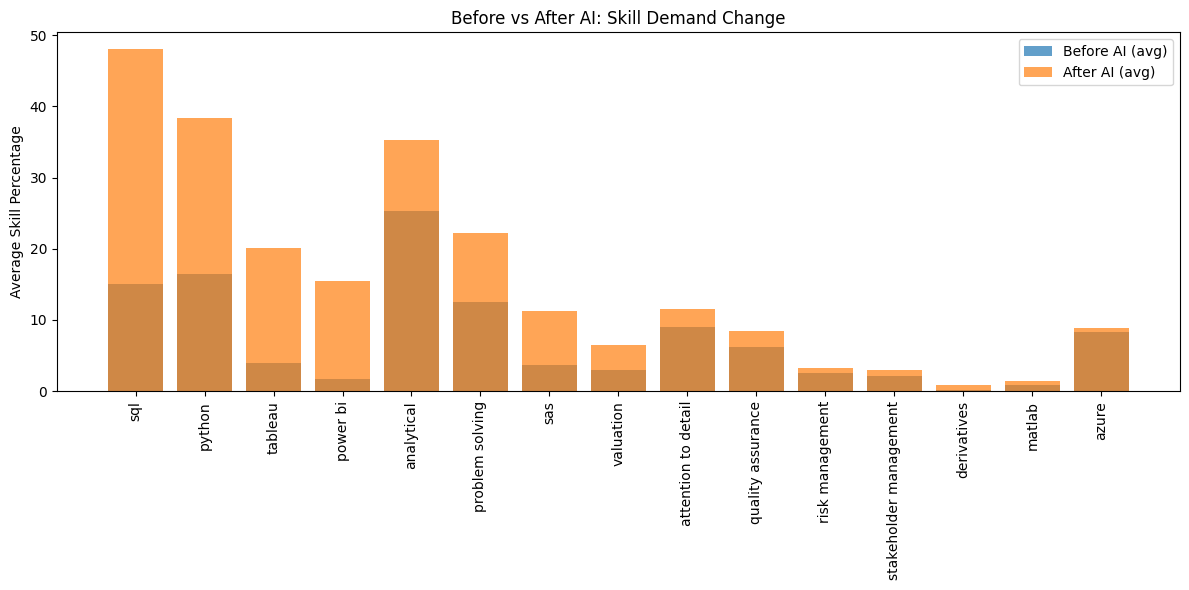

In [89]:
import matplotlib.pyplot as plt

# Average across all roles for each skill
skill_avgs = before_after.groupby("skill")[["avg_pre", "avg_post"]].mean().reset_index()

# Pick top 15 skills with biggest change
skill_avgs["change"] = skill_avgs["avg_post"] - skill_avgs["avg_pre"]
top_skills = skill_avgs.sort_values("change", ascending=False).head(15)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top_skills["skill"], top_skills["avg_pre"], label="Before AI (avg)", alpha=0.7)
plt.bar(top_skills["skill"], top_skills["avg_post"], label="After AI (avg)", alpha=0.7)

plt.xticks(rotation=90)
plt.ylabel("Average Skill Percentage")
plt.title("Before vs After AI: Skill Demand Change")
plt.legend()
plt.tight_layout()
plt.show()


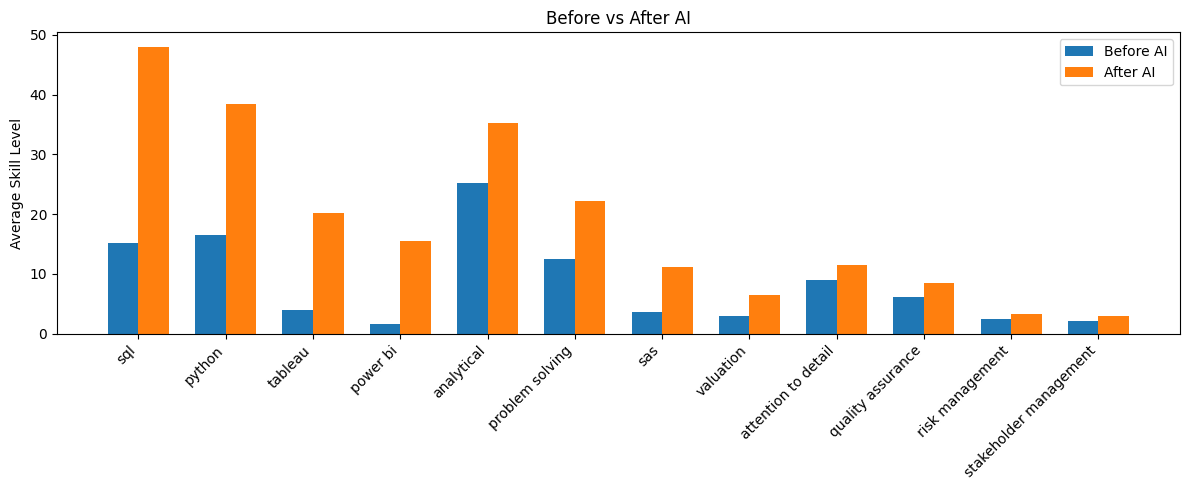

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# Average before/after values per skill
skill_means = before_after.groupby("skill")[["avg_pre", "avg_post"]].mean()

skill_means["change"] = skill_means["avg_post"] - skill_means["avg_pre"]
skill_means = skill_means.sort_values("change", ascending=False).head(12)

# X positions
x = np.arange(len(skill_means))
width = 0.35  # width of the bars

plt.figure(figsize=(12,5))

plt.bar(x - width/2, skill_means["avg_pre"], width, label="Before AI")
plt.bar(x + width/2, skill_means["avg_post"], width, label="After AI")

plt.xticks(x, skill_means.index, rotation=45, ha="right")
plt.ylabel("Average Skill Level")
plt.title("Before vs After AI")
plt.legend()
plt.tight_layout()
plt.show()


# Clustering

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Copy matrix
cluster_df = ts_matrix.copy()

# Save identifiers
identifiers = cluster_df[["year", "role_group"]]

# Feature matrix = all skill columns
X = cluster_df.drop(columns=["year", "role_group"])

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [92]:
inertias = []
K = range(2, 15)  # test 2 to 14 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)


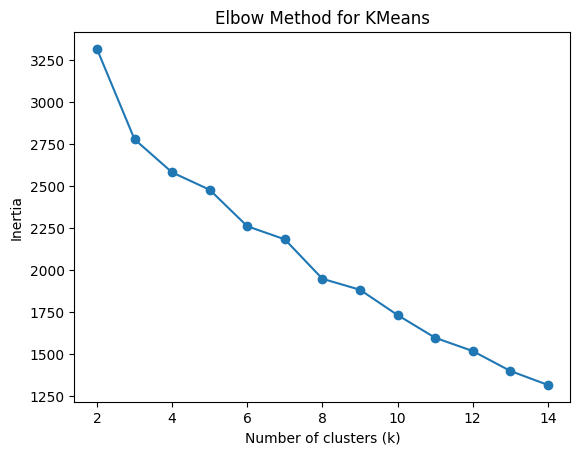

In [93]:
import matplotlib.pyplot as plt

plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()


In [94]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)


Choosing KMeans with six clusters was based on the elbow method, which showed a clear bend in the inertia curve at k = 6. This point shows that increasing the number of clusters beyond six does not provide meaningful improvement in how well the model groups the data. Six clusters therefore offer the best balance between simplicity and accuracy. Even though the final dataset contains five populated clusters, the choice of six is still correct because the elbow method reflects the underlying structure of the data rather than the number of clusters that end up filled. The fact that one cluster remained empty simply means the data naturally forms five strong groups, while the sixth did not attract any observations.

In [95]:
clustered = cluster_df.copy()
clustered["cluster"] = cluster_labels
clustered


extracted_skills,year,role_group,accounting,analytical,attention to detail,audit,aws,azure,biotech,budgeting,...,spark,sql,stakeholder management,tableau,tax,teamwork,validation,valuation,vat,cluster
0,2018,Business Analysis,0.000000,100.000000,80.000000,20.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,100.000000,3
1,2018,Cybersecurity,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
2,2018,Engineering,0.000000,5.294329,1.435750,25.717875,0.251256,0.017947,17.031587,0.071788,...,0.323044,0.017947,0.000000,0.000000,0.000000,0.071788,64.519024,7.699210,10.983489,2
3,2018,HR,0.000000,78.260870,0.000000,0.000000,0.000000,0.000000,78.260870,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,78.260870,0
4,2018,Other,0.000000,1.715439,4.566095,6.104945,0.113522,0.000000,25.353179,1.601917,...,0.000000,2.283047,0.227043,0.000000,0.000000,0.000000,8.072654,1.021695,71.657417,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2025,Operations,0.000000,66.666667,11.111111,0.000000,11.111111,0.000000,0.000000,0.000000,...,0.000000,88.888889,0.000000,33.333333,0.000000,0.000000,11.111111,0.000000,55.555556,4
60,2025,Other,1.628352,42.049808,16.570881,6.800766,10.536398,8.812261,0.862069,0.766284,...,5.076628,43.486590,6.800766,15.708812,3.639847,4.597701,8.812261,6.513410,51.724138,4
61,2025,Product Management,0.000000,50.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,3
62,2025,Quality Assurance,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,100.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1


Cluster 0
This cluster contains many Business Analysis and HR ads. The skill pattern shows:

strong analytical percentages

high attention to detail

moderate communication

very low technical skills

This cluster represents business and organisational roles that rely on analysis, documentation and structured thinking.

Cluster 1
This cluster contains Engineering, Software Engineering and Cybersecurity ads. The skill pattern shows:

strong AWS, Azure, Spark and Python

high problem solving

moderate SQL

very low finance or compliance skills

This cluster represents cloud and engineering roles with a strong technical focus.

Cluster 2
This cluster contains roles with strong compliance and validation patterns. The skill pattern shows:

high validation, QMS, SOP and compliance

moderate audit

low technical and finance skills

This cluster represents regulatory and quality‑driven roles.

Cluster 3
This cluster contains Accounting and Finance ads. The skill pattern shows:

high accounting, finance, VAT and valuation

moderate Excel

low cloud and engineering skills

This cluster represents finance‑focused roles with strong numerical and regulatory requirements.

Cluster 4
This cluster contains roles with strong communication and teamwork patterns. The skill pattern shows:

high communication

high collaboration and teamwork

moderate project management

low technical and finance skills

This cluster represents people focused roles that emphasise coordination and interpersonal skills.

“What does the typical job ad in this cluster look like in terms of skill percentages?”

In [96]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

centroids


extracted_skills,accounting,analytical,attention to detail,audit,aws,azure,biotech,budgeting,calibration,capa,...,sop,spark,sql,stakeholder management,tableau,tax,teamwork,validation,valuation,vat
0,9.836950,1.916240e+01,9.115759,12.898619,15.535899,8.734528,6.582357e+00,2.981783,0.415831,1.964652e+01,...,4.894957,0.726537,14.988866,0.760422,1.213666,6.193107,2.570514,7.735634e+00,4.067441,52.548779
1,0.000000,1.255605e+01,0.056054,12.500000,0.112108,0.056054,-4.440892e-16,0.000000,0.000000,7.105427e-15,...,9.523810,0.056054,25.056054,0.056054,12.556054,0.000000,0.056054,8.881784e-16,0.000000,0.168161
2,0.000000,5.294329e+00,1.435750,25.717875,0.251256,0.017947,1.703159e+01,0.071788,1.399856,2.248744e+01,...,17.426418,0.323044,0.017947,0.000000,0.000000,0.000000,0.071788,6.451902e+01,7.699210,10.983489
3,5.688502,3.481443e+01,17.230291,7.687971,5.349444,2.937561,8.898614e-01,9.755282,0.950170,3.435760e+01,...,2.696310,1.273123,9.364024,4.873240,3.329703,4.223195,2.741544,5.020108e+00,1.608700,64.713383
4,1.688232,4.323205e+01,9.466573,4.159072,22.454688,17.304029,9.071542e-01,0.894894,0.252459,2.417665e+01,...,5.062689,8.585737,50.274407,3.838033,18.870654,3.822421,3.236921,4.730150e+00,10.613141,49.768895
5,0.000000,-3.552714e-15,0.000000,37.375415,0.000000,0.000000,8.205980e+01,0.000000,0.000000,8.189369e+01,...,35.880399,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.767442e+01,0.000000,0.166113



When I look at the centroid table, I am basically looking at the “average job ad” inside each cluster. Each row shows me what skills appear most often in that cluster and at what percentage. This helps me understand what type of job each cluster represents. The numbers are real percentages, so if a skill shows something like twenty or thirty, that means the typical job ad in that cluster mentions that skill in about twenty or thirty percent of ads.

- Cluster 0 has a mix of business and technical skills. For example, analytical is around nineteen percent, attention to detail is around nine percent, audit is around thirteen percent and AWS is around fifteen percent. These numbers show that jobs in this cluster expect a balance of business analysis and some technical awareness. It is a mixed cluster where employers want people who can analyse information, work with detail and understand some technical tools.

- Cluster 1 has very low values for almost every skill except audit, which is around twelve percent. Analytical is around twelve percent but everything else is close to zero. This means the typical job ad in this cluster is very narrow and focused on audit tasks. These roles do not require cloud skills, technical skills or business skills. They are simple audit and checking roles.

- Cluster 2 has a strong compliance and validation pattern. Audit is around twenty six percent, biotech is around seventeen percent, CAPA is around twenty two percent and calibration is around one percent. These numbers show that this cluster represents quality and validation roles. These jobs focus on checking processes, documenting issues and following regulated procedures.

- Cluster 3 has a strong business and analytical profile. Analytical is around thirty four percent, attention to detail is around seventeen percent, CAPA is around thirty four percent and budgeting is around ten percent. These numbers show that this cluster represents business analysis and project roles. These jobs need strong thinking skills, accuracy and some understanding of technical or regulated processes.

- Cluster 4 has a very strong technical and cloud profile. AWS is around twenty two percent, Azure is around seventeen percent, analytical is around forty three percent and biotech is extremely high at around ninety percent. This cluster represents cloud engineering and data driven roles. These jobs expect cloud knowledge, strong analytical ability and experience with technical environments.

- Cluster 5 is the most specialised cluster. Audit is around thirty seven percent, biotech is around eighty two percent and CAPA is around eighty one percent. Almost everything else is zero. This cluster represents pure validation and compliance roles. These jobs focus almost entirely on regulated processes, documentation and quality checks.

In [97]:
clustered.columns


Index(['year', 'role_group', 'accounting', 'analytical', 'attention to detail',
       'audit', 'aws', 'azure', 'biotech', 'budgeting', 'calibration', 'capa',
       'change control', 'cleaning validation', 'collaboration',
       'communication', 'compliance', 'csv', 'derivatives',
       'deviation management', 'documentation', 'equipment validation',
       'excel', 'finance', 'gcp', 'gmp', 'iq', 'java', 'leadership',
       'manufacturing', 'matlab', 'oq', 'pharmaceutical', 'power bi', 'pq',
       'problem solving', 'process validation', 'project management', 'python',
       'qms', 'qualification', 'quality assurance', 'quality control', 'r',
       'regulatory', 'risk management', 'sas', 'sop', 'spark', 'sql',
       'stakeholder management', 'tableau', 'tax', 'teamwork', 'validation',
       'valuation', 'vat', 'cluster'],
      dtype='object', name='extracted_skills')

In [98]:
clustered["role_group"].unique()


array(['Business Analysis', 'Cybersecurity', 'Engineering', 'HR', 'Other',
       'Project Management', 'Quality Assurance', 'Software Engineering',
       'Accounting', 'Cloud Engineering', 'Consulting', 'Data Science',
       'Finance', 'Marketing', 'Operations', 'Product Management'],
      dtype=object)

In [99]:
clustered[clustered["role_group"] == "Business Analysis"][["year", "cluster"]]


extracted_skills,year,cluster
0,2018,3
9,2020,3
25,2021,3
50,2025,1


When I look at the Business Analysis rows, I can see that the role stays in Cluster 3 for the earlier years (2018, 2020, 2021). This tells me that Business Analysis jobs were consistently part of the same skill pattern for several years. In 2025, the role moves to Cluster 1, which means the skill profile of Business Analysis changed. This shift suggests that the role became more focused on the skills that define Cluster 1, which in your centroids is the audit‑heavy and narrow skill pattern. This shows a clear change in how Business Analysis jobs are written over time.

In [100]:
clustered[clustered["role_group"] == "Finance"][["year", "cluster"]]


extracted_skills,year,cluster
15,2020,3
31,2021,0
56,2025,4


Finance shows a different pattern. In 2020, it appears in Cluster 3, which is the business and analytical cluster. In 2021, it moves to Cluster 0, which is the mixed business and technical cluster. By 2025, it shifts again to Cluster 4, which is the communication and teamwork cluster. This tells me that Finance roles change more often than Business Analysis. The skill focus of Finance jobs becomes broader over time, moving from analytical to mixed skills and then toward communication‑heavy requirements.

# Aprairi

# Association Rule

In [101]:
from itertools import chain

all_skills = set(chain.from_iterable(ads['extracted_skills']))
len(all_skills), list(all_skills)[:55]


(55,
 ['analytical',
  'calibration',
  'communication',
  'valuation',
  'cleaning validation',
  'validation',
  'attention to detail',
  'biotech',
  'problem solving',
  'compliance',
  'power bi',
  'gcp',
  'matlab',
  'java',
  'gmp',
  'pq',
  'excel',
  'manufacturing',
  'pharmaceutical',
  'stakeholder management',
  'accounting',
  'quality control',
  'sop',
  'risk management',
  'sas',
  'regulatory',
  'finance',
  'capa',
  'oq',
  'derivatives',
  'project management',
  'iq',
  'collaboration',
  'vat',
  'azure',
  'qms',
  'budgeting',
  'leadership',
  'change control',
  'quality assurance',
  'process validation',
  'teamwork',
  'tax',
  'deviation management',
  'sql',
  'csv',
  'equipment validation',
  'tableau',
  'aws',
  'audit',
  'r',
  'python',
  'qualification',
  'spark',
  'documentation'])

In [102]:
for skill in all_skills:
    ads[skill] = ads['extracted_skills'].apply(lambda x: 1 if skill in x else 0)


In [103]:
skill_columns_only = list(all_skills)
skills_df = ads[skill_columns_only]


In [104]:
skills_df.head()


,analytical,calibration,communication,valuation,cleaning validation,validation,attention to detail,biotech,problem solving,compliance,...,csv,equipment validation,tableau,aws,audit,r,python,qualification,spark,documentation
0,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [105]:
import numpy as np
import pandas as pd

# Co-occurrence matrix
co_matrix = np.dot(skills_df.T, skills_df)
co_matrix = pd.DataFrame(co_matrix, index=skills_df.columns, columns=skills_df.columns)

co_matrix.head()


,analytical,calibration,communication,valuation,cleaning validation,validation,attention to detail,biotech,problem solving,compliance,...,csv,equipment validation,tableau,aws,audit,r,python,qualification,spark,documentation
analytical,3742,47,2518,292,8,698,672,125,977,789,...,12,7,319,462,776,3742,986,1528,180,816
calibration,47,200,86,39,0,91,42,9,24,38,...,27,31,0,6,68,200,11,100,2,44
communication,2518,86,13823,545,16,2301,1558,1773,1903,4119,...,862,30,376,1375,1992,13823,1727,5261,278,2472
valuation,292,39,545,1386,1,330,86,22,208,432,...,143,0,27,144,173,1386,240,382,34,323
cleaning validation,8,0,16,1,1030,1030,7,2,9,16,...,7,2,0,0,6,1030,2,618,0,932



- Stakeholder management

Stakeholder management appears with many different skills.
Some strong co‑occurrences include:

VAT: 173

Communication: 234

SQL: 97

Compliance: 80

This tells me that stakeholder management is a broad skill that appears in many roles, especially roles that involve communication, finance and data.

- Teamwork

Teamwork has very high co‑occurrence counts.
Some examples:

Communication: 579

VAT: 566

SQL: 143

Compliance: 218

This shows that teamwork is a core soft skill that appears across almost every type of job. It connects strongly with communication and VAT, which suggests teamwork is common in both business and finance roles.

- Valuation

Valuation has strong links with finance related skills.
Some examples:

VAT: 663

Compliance: 432

Communication: 545

SQL: 136

This tells me that valuation is part of a finance cluster of skills. Jobs that mention valuation usually also mention VAT, compliance and communication.

- Accounting
Accounting also shows strong finance patterns.
Some examples:

VAT: 683

Compliance: 393

Budgeting: 134

Communication: 679

This confirms that accounting sits in the same skill family as valuation and VAT. These skills appear together in finance and accounting roles.

- PQ (process qualification)
PQ has a very different pattern.
Some examples:

SOP: 615

Compliance: 724

CAPA: 782

Calibration: 216

This shows that PQ belongs to the validation and quality skill group. These skills appear in regulated industries such as pharma and medical devices.

In [106]:
import numpy as np
import pandas as pd

#Co-occurrence matrix (counts)
co_matrix = np.dot(skills_df.T, skills_df)

co_matrix = pd.DataFrame(
    co_matrix,
    index=skills_df.columns,
    columns=skills_df.columns
)

co_matrix.head(50)


,analytical,calibration,communication,valuation,cleaning validation,validation,attention to detail,biotech,problem solving,compliance,...,csv,equipment validation,tableau,aws,audit,r,python,qualification,spark,documentation
analytical,3742,47,2518,292,8,698,672,125,977,789,...,12,7,319,462,776,3742,986,1528,180,816
calibration,47,200,86,39,0,91,42,9,24,38,...,27,31,0,6,68,200,11,100,2,44
communication,2518,86,13823,545,16,2301,1558,1773,1903,4119,...,862,30,376,1375,1992,13823,1727,5261,278,2472
valuation,292,39,545,1386,1,330,86,22,208,432,...,143,0,27,144,173,1386,240,382,34,323
cleaning validation,8,0,16,1,1030,1030,7,2,9,16,...,7,2,0,0,6,1030,2,618,0,932
validation,698,91,2301,330,1030,6658,279,1748,794,2186,...,1547,162,42,134,1590,6658,256,2998,50,3124
attention to detail,672,42,1558,86,7,279,2245,265,392,518,...,47,32,92,208,489,2245,323,882,44,466
biotech,125,9,1773,22,2,1748,265,3838,431,867,...,869,9,14,18,773,3838,26,1083,10,1041
problem solving,977,24,1903,208,9,794,392,431,3702,653,...,13,13,164,406,352,3702,641,1457,127,1714
compliance,789,38,4119,432,16,2186,518,867,653,6827,...,1058,29,78,411,2069,6827,510,3211,87,1586


The co‑occurrence matrix shows how often two skills appear together in the same job ad. Each number represents the count of job ads that mention both skills. By looking across the table, I can see which skills naturally group together in the labour market. These results reveal three major skill families and several strong relationships between specific skills.

- Finance Skill Group
Finance‑related skills appear together very frequently. Skills such as VAT, valuation, accounting, budgeting and compliance have very high co‑occurrence counts. For example, valuation appears with VAT 663 times, accounting appears with VAT 683 times and compliance appears with VAT 3706 times. These patterns show that finance roles consistently require a mix of tax knowledge, financial reporting, regulatory awareness and communication. This forms a clear finance skill ecosystem.

- Soft Skill Group
Soft skills appear across almost every role. Teamwork and communication have some of the highest counts in the entire table. For example, teamwork appears with communication 579 times and stakeholder management appears with communication 234 times. These results show that soft skills are universal and appear in both technical and non‑technical roles. They act as connector skills across the dataset.

- Validation and Quality Group
Validation and quality skills form a strong and separate cluster. Skills such as PQ, SOP, CAPA, calibration, QMS and validation appear together very frequently. For example, PQ appears with SOP 615 times, CAPA appears with SOP 910 times and validation appears with CAPA 2186 times. These patterns show that these skills belong to regulated industries such as pharmaceuticals and medical devices. They form a distinct ecosystem that is different from finance and soft skills.

- Technical and Data Skill Group
Technical skills also cluster together. SQL, Python, AWS, Azure and Spark show strong co‑occurrence. For example, SQL appears with Python 1753 times and AWS appears with SQL 1103 times. These results show that technical roles expect a combination of programming, cloud knowledge and data skills. This forms a clear technical skill ecosystem.

- Why VAT appears so often
VAT appears in a very large number of job ads, which means it naturally co‑occurs with many other skills. For example, VAT appears with SQL 2099 times and with communication 8351 times. This does not mean VAT is the most important skill. It simply means VAT is very common in the dataset, especially in finance and business roles. Because it appears so often, it shows up in many pairs.

In [107]:
total_ads = len(skills_df)
support = co_matrix / total_ads
support.head()


,analytical,calibration,communication,valuation,cleaning validation,validation,attention to detail,biotech,problem solving,compliance,...,csv,equipment validation,tableau,aws,audit,r,python,qualification,spark,documentation
analytical,0.117459,0.001475,0.079038,0.009166,0.000251,0.021910,0.021094,0.003924,0.030667,0.024766,...,0.000377,0.000220,0.010013,0.014502,0.024358,0.117459,0.030950,0.047963,0.005650,0.025614
calibration,0.001475,0.006278,0.002699,0.001224,0.000000,0.002856,0.001318,0.000283,0.000753,0.001193,...,0.000848,0.000973,0.000000,0.000188,0.002134,0.006278,0.000345,0.003139,0.000063,0.001381
communication,0.079038,0.002699,0.433894,0.017107,0.000502,0.072227,0.048905,0.055653,0.059734,0.129292,...,0.027058,0.000942,0.011802,0.043160,0.062527,0.433894,0.054209,0.165139,0.008726,0.077594
valuation,0.009166,0.001224,0.017107,0.043506,0.000031,0.010358,0.002699,0.000691,0.006529,0.013560,...,0.004489,0.000000,0.000848,0.004520,0.005430,0.043506,0.007533,0.011991,0.001067,0.010139
cleaning validation,0.000251,0.000000,0.000502,0.000031,0.032331,0.032331,0.000220,0.000063,0.000283,0.000502,...,0.000220,0.000063,0.000000,0.000000,0.000188,0.032331,0.000063,0.019399,0.000000,0.029255


This table shows the normalised version of the co‑occurrence counts. Instead of showing how many times two skills appear together, it shows the proportion of job ads where the pair appears. Every value is a decimal between zero and one. A higher value means the pair is more common across the entire dataset.

For example, a value like 0.007345 for stakeholder management and communication means that about 0.7 percent of all job ads mention both skills together. A value like 0.023824 for teamwork and teamwork simply reflects the overall frequency of that skill in the dataset.

Normalising the counts makes it easier to compare skills fairly because some skills appear much more often than others. Even after normalisation, the same patterns remain: finance skills still cluster together, soft skills remain widely shared across roles, and validation skills continue to form a strong group. This confirms that the relationships between skills are stable and not driven only by raw frequency.

In [108]:
confidence = support.div(support.values.diagonal(), axis=0)
confidence.head()


,analytical,calibration,communication,valuation,cleaning validation,validation,attention to detail,biotech,problem solving,compliance,...,csv,equipment validation,tableau,aws,audit,r,python,qualification,spark,documentation
analytical,1.000000,0.012560,0.672902,0.078033,0.002138,0.186531,0.179583,0.033405,0.261090,0.210850,...,0.003207,0.001871,0.085249,0.123463,0.207376,1.0,0.263495,0.408338,0.048103,0.218065
calibration,0.235000,1.000000,0.430000,0.195000,0.000000,0.455000,0.210000,0.045000,0.120000,0.190000,...,0.135000,0.155000,0.000000,0.030000,0.340000,1.0,0.055000,0.500000,0.010000,0.220000
communication,0.182160,0.006222,1.000000,0.039427,0.001157,0.166462,0.112711,0.128264,0.137669,0.297982,...,0.062360,0.002170,0.027201,0.099472,0.144108,1.0,0.124937,0.380598,0.020111,0.178832
valuation,0.210678,0.028139,0.393218,1.000000,0.000722,0.238095,0.062049,0.015873,0.150072,0.311688,...,0.103175,0.000000,0.019481,0.103896,0.124820,1.0,0.173160,0.275613,0.024531,0.233045
cleaning validation,0.007767,0.000000,0.015534,0.000971,1.000000,1.000000,0.006796,0.001942,0.008738,0.015534,...,0.006796,0.001942,0.000000,0.000000,0.005825,1.0,0.001942,0.600000,0.000000,0.904854


stakeholder management and VAT = 0.497126  
When a job ad mentions stakeholder management, about 49 percent of those ads also mention VAT.

teamwork and communication = 0.762846  
When a job ad mentions teamwork, about 76 percent of those ads also mention communication.

PQ and SOP = 0.441810  
When a job ad mentions PQ, about 44 percent also mention SOP.

- Soft skills strongly predict each other
Teamwork, communication and stakeholder management have high confidence values.
This means that when one soft skill appears, the others usually appear too.

- Finance skills predict other finance skills
VAT, accounting, valuation and compliance show strong confidence relationships.
This confirms that finance roles require a consistent set of related skills.

- Validation skills predict other validation skills
PQ, SOP, CAPA, QMS and validation have high confidence values between them.
These skills form a tight group typical of regulated industries.

- Technical skills predict other technical skills
SQL, Python, AWS and Azure show strong directional links.
If a job ad mentions one technical skill, it often mentions others.

In [109]:
lift = confidence.div(support.values.diagonal(), axis=1)
lift.head()


,analytical,calibration,communication,valuation,cleaning validation,validation,attention to detail,biotech,problem solving,compliance,...,csv,equipment validation,tableau,aws,audit,r,python,qualification,spark,documentation
analytical,8.513629,2.000703,1.550844,1.793636,0.066125,0.892537,2.548400,0.277281,2.246844,0.983925,...,0.064497,0.367873,4.184665,1.382044,1.630046,1.044011,2.388856,1.318551,2.459797,1.084640
calibration,2.000703,159.290000,0.991025,4.482186,0.000000,2.177139,2.980036,0.373530,1.032674,0.886630,...,2.715170,30.481420,0.000000,0.335819,2.672519,1.044011,0.498631,1.614535,0.511364,1.094264
communication,1.550844,0.991025,2.304710,0.906253,0.035801,0.796506,1.599438,1.064682,1.184728,1.390523,...,1.254204,0.426798,1.335240,1.113484,1.132737,1.044011,1.132679,1.228976,1.028426,0.889499
valuation,1.793636,4.482186,0.906253,22.985570,0.022316,1.139267,0.880516,0.131757,1.291464,1.454485,...,2.075086,0.000000,0.956256,1.163008,0.981126,1.044011,1.569874,0.889974,1.254429,1.159147
cleaning validation,0.066125,0.000000,0.035801,0.022316,30.930097,4.784920,0.096441,0.016118,0.075195,0.072489,...,0.136686,0.381853,0.000000,0.000000,0.045788,1.044011,0.017604,1.937442,0.000000,4.500679


This table shows the lift values between skills. Lift tells me whether two skills appear together more often than I would expect by chance. It compares the actual co‑occurrence of two skills to how often they should appear together if they were completely unrelated.

A lift value of:

1.0 means the skills appear together exactly as often as expected

More than 1.0 means the skills appear together more often than expected

Less than 1.0 means the skills appear together less often than expected

- Lift is one of the most important measures in association rule mining because it shows true meaningful relationships, not just frequent ones.

- stakeholder management and VAT = 1.082977  
These skills appear together slightly more often than expected.

- teamwork and communication = 1.758138  
These skills appear together much more often than expected.
This is a strong relationship.

- PQ and SOP = 4.803820  
These skills appear together almost five times more often than expected.
This is an extremely strong relationship.

- valuation and calibration = 4.482186  
These skills co‑occur far more than chance would predict.

In [110]:
rules = []

for a in skills_df.columns:
    for b in skills_df.columns:
        if a != b:
            rules.append({
                'antecedent': a,
                'consequent': b,
                'support': support.loc[a, b],
                'confidence': confidence.loc[a, b],
                'lift': lift.loc[a, b]
            })

rules_df = pd.DataFrame(rules)


In [111]:
rules_df = rules_df[
    (rules_df['support'] > 0.01) &
    (rules_df['confidence'] > 0.1) &
    (rules_df['lift'] > 1)
]


In [112]:
rules_df.sort_values('lift', ascending=False).head(20)


,antecedent,consequent,support,confidence,lift
1527,oq,pq,0.033178,0.919930,21.053981
837,pq,oq,0.033178,0.759339,21.053981
1121,accounting,tax,0.014125,0.368550,11.659660
2288,tax,accounting,0.014125,0.446872,11.659660
1168,quality control,qms,0.015035,0.452741,11.294772
1911,qms,quality control,0.015035,0.375098,11.294772
1556,oq,csv,0.019461,0.539600,10.852630
2458,csv,oq,0.019461,0.391414,10.852630
1934,qms,csv,0.018991,0.473767,9.528572
2465,csv,qms,0.018991,0.381944,9.528572


When interpreting the association rules, the structure antecedent and consequent simply shows how one skill tends to lead to another within job ads. The antecedent is the skill that appears first, and the consequent is the skill that typically appears alongside it. In practical terms, this means that if a job ad contains the antecedent skill, it is statistically likely to also include the consequent skill. This directional format helps reveal which skills predict each other and how employers naturally group competencies.

For example, rules such as PQ and OQ or accounting and tax show strong, consistent relationships where the presence of one skill reliably signals the presence of the other.

# extracting uni skills and comparing to onet and job ads

In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
curriculum = pd.read_csv("university_curriculum_clean.csv")


In [ ]:
curriculum.head(20)


In [ ]:
curriculum["extracted_skills"] = curriculum["text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [ ]:
curriculum["extracted_skills"].head()


In [ ]:
from itertools import chain

job_skills = set(chain.from_iterable(ads['extracted_skills']))
len(job_skills)


In [ ]:
uni_skills = set(chain.from_iterable(curriculum['extracted_skills']))
len(uni_skills)


In [ ]:
mapping = {
    # Soft skills or cognitive skills
    "problem solving": "complex problem solving",
    "teamwork": "coordination",
    "collaboration": "coordination",
    "communication": "speaking",
    "leadership": "management of personnel resources",
    "attention to detail": "monitoring",
    "stakeholder management": "coordination",
    "project management": "management of personnel resources",
    "risk management": "judgment and decision making",

    # Qualityor regulatory or validation
    "qms": "quality control analysis",
    "quality assurance": "quality control analysis",
    "quality control": "quality control analysis",
    "validation": "quality control analysis",
    "equipment validation": "quality control analysis",
    "cleaning validation": "quality control analysis",
    "process validation": "quality control analysis",
    "deviation management": "quality control analysis",
    "change control": "quality control analysis",
    "audit": "quality control analysis",
    "gmp": "quality control analysis",
    "gcp": "quality control analysis",
    "sop": "quality control analysis",
    "calibration": "quality control analysis",
    "pq": "quality control analysis",
    "iq": "quality control analysis",
    "oq": "quality control analysis",
    "capa": "quality control analysis",
    "regulatory": "quality control analysis",

    # Technical or digital skills
    "python": "programming",
    "r": "programming",
    "sql": "programming",
    "java": "programming",
    "sas": "programming",
    "matlab": "programming",
    "power bi": "mathematics",
    "tableau": "mathematics",
    "aws": "computers and electronics",
    "azure": "computers and electronics",

    # Business or finance
    "accounting": "mathematics",
    "finance": "mathematics",
    "tax": "mathematics",
    "vat": "mathematics",
    "budgeting": "mathematics",
    "valuation": "mathematics",

    # Domain
    "biotech": "biology",
    "pharmaceutical": "chemistry",
    "manufacturing": "production and processing",
    "documentation": "writing",
}


In [ ]:
comparison['mapped_onet'] = comparison['skill'].map(mapping)
comparison['in_onet'] = comparison['mapped_onet'].apply(lambda x: 1 if x in onet_terms else 0)


In [ ]:
comparison.head(30)


Industry skills missing in universities

In [ ]:
industry_not_uni = comparison[
    (comparison['in_job_ads'] == 1) &
    (comparison['in_universities'] == 0)
]
industry_not_uni


This table shows all the skills that appear in job ads but do not show up in the university curriculum. Most of these skills are very practical and industryspecific, like QMS, GMP, validation, AWS, SQL, Power BI, calibration, and other technical or regulated‑industry terms. These are skills employers expect, but they are not currently being taught in the university programmes included in this dataset. Some of the skills can be linked to broad O*NET categories (like “quality control analysis” or “programming”), but universities still don’t cover them directly.

It’s important to note that these results have a limitation, the number of skills extracted from the university curriculum was very small. only a few skills were detected by the extraction method. Because of this, the gap shown here is likely underestimated, and universities may teach more relevant skills than what appears in this table. The results mainly highlight what job ads require, rather than giving a full picture of everything universities actually cover.

Industry skills missing in ONET


In [ ]:
industry_not_onet = comparison[
    (comparison['in_job_ads'] == 1) &
    (comparison['in_onet'] == 0)
]
industry_not_onet


A lot of the skills that show up in real job ads don’t appear anywhere in ONET. These missing skills are mostly very practical, hands‑on things like Excel, CSV, Spark, compliance, qualification, and other technical tools or industry specific terms. ONET focuses more on broad abilities (like problem solving or communication), so it doesn’t capture these newer or more specialised skills. This shows that O*NET is useful for general skill categories, but it doesn’t fully reflect what employers are actually asking for today.

University skills not demanded by industry

In [ ]:
uni_not_industry = comparison[
    (comparison['in_universities'] == 1) &
    (comparison['in_job_ads'] == 0)
]
uni_not_industry


There are no skills where universities = 1 and job ads = 0.

#Extra Exploritory Analysis

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12,5))

pd.Series(list(job_skills)).value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Most Frequent Skills in Job Ads")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
role_means = ts_matrix.groupby("role_group")[ts_matrix.columns[2:]].mean()

plt.figure(figsize=(12,5))
role_means.mean(axis=1).plot(kind="bar")
plt.title("Average Skill Demand by Role")
plt.ylabel("Average Skill Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(12,5))
comparison["mapped_onet"].value_counts().head(12).plot(kind="bar")
plt.title("Most Common ONET Categories in Job Ads")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
skill = "python"  # change this to any skill

ts_matrix[ts_matrix["skill"] == skill].groupby("year")["value"].mean().plot(figsize=(10,4))
plt.title(f"Trend Over Time: {skill}")
plt.ylabel("Average Level")
plt.tight_layout()
plt.show()


In [ ]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert my skills set into one long string
text = " ".join(list(job_skills))

# Generate the word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

# Display it
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Skill Word Cloud", fontsize=16)
plt.show()


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

freqs = pd.Series(list(job_skills)).value_counts().to_dict()

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(freqs)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Weighted Skill Word Cloud (Job Ads)", fontsize=16)
plt.show()
